In [1]:
from pathlib import Path
import sys
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

%load_ext autoreload
%autoreload 2
import soccer_pattern_recognition as sc

import os
import time
import tqdm
import numpy as np
import pandas as pd

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 154.27it/s]


In [3]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions

def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions

In [4]:
def _add_sequence_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Given a dataframe with a boolean column `new_poss`,
    add:
        - poss_id
        - idx_in_seq
        - seq_length
    """
    df = df.copy()

    df["poss_id"] = df["new_poss"].cumsum()
    df["idx_in_seq"] = df.groupby("poss_id").cumcount()
    df["seq_length"] = df.groupby("poss_id")["poss_id"].transform("size")

    return df

def prepare_data(actions: pd.DataFrame, action_map: dict):
    """
    Prepare soccer action data for modeling.

    Steps
    -----
    1. Consolidate and perturb coordinates.
    2. Compute action angle and its cosine/sine.
    3. Map action names to integer ids.
    4. Detect possession boundaries.
    5. Build possession sequence features.
    6. Keep only modeled actions and sequences of length >= 3.
    7. Recompute sequence indexing after filtering.
    8. Return feature matrix X and sequence lengths.

    Returns
    -------
    X : np.ndarray
        Array with columns:
        [action_type_id, start_x, start_y, cos_angle, sin_angle]

    lengths : np.ndarray
        Length of each possession sequence, in possession-id order.
    """
    actions = actions.copy()

    # Basic preprocessing
    actions = consolidate(actions)
    actions = add_noise(actions)

    # Directional features
    dx = actions["end_x"] - actions["start_x"]
    dy = actions["end_y"] - actions["start_y"]
    actions["angle"] = np.arctan2(dy, dx)
    actions["cos_angle"] = np.cos(actions["angle"])
    actions["sin_angle"] = np.sin(actions["angle"])

    # Action id
    actions["action_type_id"] = actions["type_name"].map(action_map)

    # Possession starts
    actions["new_poss"] = (
        (actions.index == 0)
        | (actions["game_id"] != actions["game_id"].shift(1))
        | (actions["period_id"] != actions["period_id"].shift(1))
        | (actions["team_id"] != actions["team_id"].shift(1))
        | (actions["type_name"] == "goalkick")
        | (actions["type_name"] == "freekick")
        | (actions["type_name"].shift(1) == "shot")
        | (actions["type_name"].shift(1) == "bad_touch")
        | (actions["type_name"].shift(1) == "foul")
    )

    # Add initial sequence info
    actions = _add_sequence_columns(actions)

    # Keep only actions modeled in action_map and sequences with length >= 3
    valid_action = actions["type_name"].isin(action_map)
    long_enough_seq = actions["seq_length"] >= 3
    df = actions.loc[valid_action & long_enough_seq].copy()

    # IMPORTANT:
    # after filtering, rebuild new_poss so sequence boundaries are still valid
    # in the filtered dataframe
    df["new_poss"] = (
        (df.index == df.index[0])
        | (df["game_id"] != df["game_id"].shift(1))
        | (df["period_id"] != df["period_id"].shift(1))
        | (df["team_id"] != df["team_id"].shift(1))
        | (df["type_name"] == "goalkick")
        | (df["type_name"] == "freekick")
        | (df["type_name"].shift(1) == "shot")
        | (df["type_name"].shift(1) == "bad_touch")
        | (df["type_name"].shift(1) == "foul")
    )

    df = _add_sequence_columns(df)

    # Feature matrix
    X = df[[
        "action_type_id",
        "start_x",
        "start_y",
        "cos_angle",
        "sin_angle",
    ]].to_numpy()

    # One length per possession
    lengths = (
        df.groupby("poss_id")
        .size()
        .to_numpy()
    )

    return X, lengths

In [5]:
emission_hyperparams = {'clearance': [4, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [4, "k-means",2,"k-means"],
              'dribble': [5, "k-means",2,"k-means"],
              'freekick': [3, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [3, "k-means",2,"k-means"],
              'pass': [5, "k-means",2,"k-means"],
              'shot': [3, "k-means",2,"k-means"],
              'throw_in': [6, "k-means",2,"k-means"]}

models = {n_states: sc.TwoLayerHMM(emission_hyperparams,n_states)
          for n_states in range(2,5)}


In [6]:
ACTION_MAP = {'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

X, lenghts = prepare_data(actions, ACTION_MAP)

In [7]:
models[2].fit(X, lenghts)

,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,2
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [8]:
models[3].fit(X, lenghts)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:103: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(loc_pdf) + dir_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,3
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [9]:
models[4].fit(X, lenghts)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:103: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(loc_pdf) + dir_log_pdf, axis=1)  # (N,)
/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hmm/base.py:167: RuntimeWarning: Sum of gamma is not positive; skipping this batch in stats accumulation.
  self.emission.accumulate_sufficient_statistics(


,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,4
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [12]:
np.set_printoptions(precision=4, suppress=True)

for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    print("Start probabilities")
    print(model.startprob_)
    print("\nTransition matrix")
    print(model.transmat_)
    print(f"\n")

Model with 2 states:
Start probabilities
[0.6005 0.3995]

Transition matrix
[[0.0941 0.9059]
 [0.96   0.04  ]]


Model with 3 states:
Start probabilities
[0.6101 0.0391 0.3507]

Transition matrix
[[0.0777 0.0304 0.8919]
 [0.1018 0.0021 0.8961]
 [0.7421 0.2262 0.0317]]


Model with 4 states:
Start probabilities
[0.7671 0.0046 0.0189 0.2094]

Transition matrix
[[0.416  0.4118 0.0006 0.1716]
 [0.9759 0.0025 0.     0.0216]
 [0.0192 0.0994 0.3091 0.5723]
 [0.0087 0.0006 0.1471 0.8436]]




In [15]:
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for action in ACTION_MAP.keys():
        for state in range(2):
            print(f"   State: {state}, {action}")
            print(model.emission.action_mom_[state][action].layer1_mixture)
            print(model.emission.action_mom_[state][action].layer2_mixtures)
    print(f"\n")

Model with 2 states:
   State: 0, clearance
MixtureModel(n_components=4)
  ├─ (0) w=0.538  MultivariateGaussian(d=2, mean=[ 7.139 34.448], cov=[[6.032 1.644], [ 1.644 27.488]])
  ├─ (1) w=0.157  MultivariateGaussian(d=2, mean=[11.957 23.718], cov=[[29.778  1.381], [ 1.381 39.988]])
  ├─ (2) w=0.224  MultivariateGaussian(d=2, mean=[12.503 38.671], cov=[[15.841 -2.62 ], [-2.62  44.516]])
  └─ (3) w=0.080  MultivariateGaussian(d=2, mean=[16.836 49.083], cov=[[92.971  7.695], [  7.695 128.743]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.497  VonMises(loc=62.9 deg, kappa=2.899)
  └─ (1) w=0.503  VonMises(loc=-48.4 deg, kappa=2.556), MixtureModel(n_components=2)
  ├─ (0) w=0.440  VonMises(loc=44.2 deg, kappa=2.167)
  └─ (1) w=0.560  VonMises(loc=-42.0 deg, kappa=2.281), MixtureModel(n_components=2)
  ├─ (0) w=0.522  VonMises(loc=49.4 deg, kappa=2.817)
  └─ (1) w=0.478  VonMises(loc=-43.7 deg, kappa=1.510), MixtureModel(n_components=2)
  ├─ (0) w=0.593  VonMises(loc=46.3 deg, kappa=2.827)
  

In [21]:
for n_state, model in models.items():
    print(f"\nModel with {n_state} states:")
    df = pd.DataFrame(model.emission.action_pi_).round(4) * 100
    df.index = [f"S{i}" for i in df.index]
    print(df.to_string())


Model with 2 states:
    clearance  corner  cross  dribble  freekick  goalkick  keeper_action   pass  shot  throw_in
S0       0.54    0.17   1.95     1.24      1.17      0.42           0.44  90.34  1.29      2.44
S1       0.30    0.27   0.18    95.99      0.08      0.07           0.12   1.78  0.66      0.54

Model with 3 states:
    clearance  corner  cross  dribble  freekick  goalkick  keeper_action   pass  shot  throw_in
S0       0.77    0.21   1.45     2.04      1.57       0.6           0.67  89.67  1.07      1.95
S1       0.09    0.07   3.77     0.68      0.00       0.0           0.01  87.94  2.04      5.41
S2       0.21    0.26   0.16    96.96      0.00       0.0           0.01   1.52  0.66      0.23

Model with 4 states:
    clearance  corner  cross  dribble  freekick  goalkick  keeper_action   pass  shot  throw_in
S0       1.36    0.11   0.02    47.45      2.27      0.87           0.97  43.50  0.02      3.44
S1       0.12    0.67   0.10    38.18      0.00      0.01           0.

Model with 2 states:


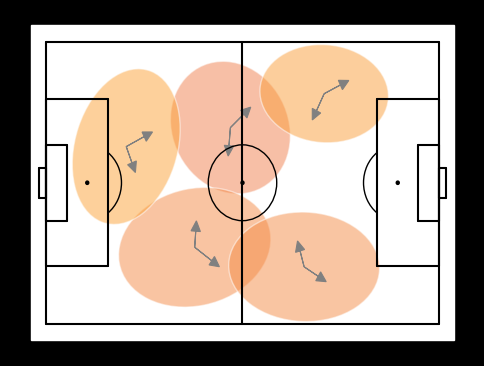

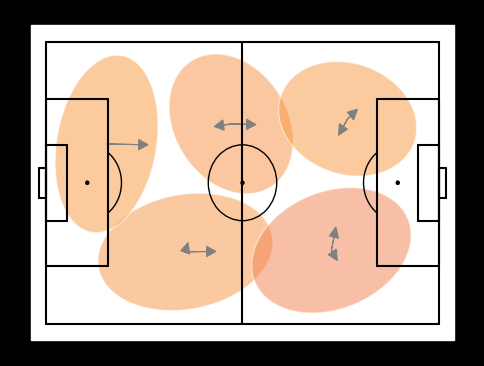

Model with 3 states:


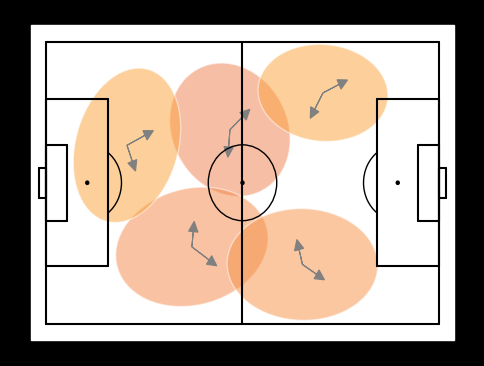

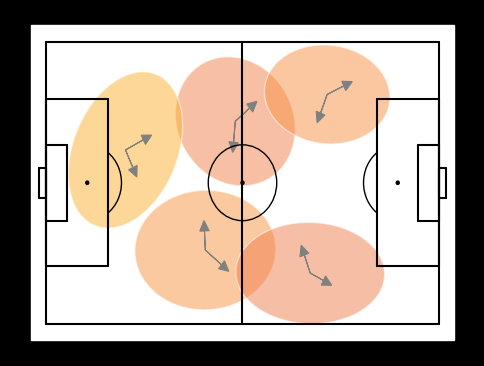

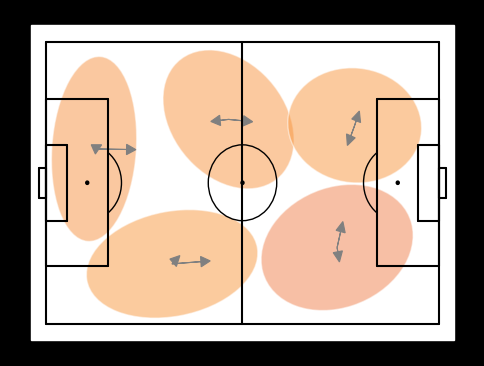

Model with 4 states:


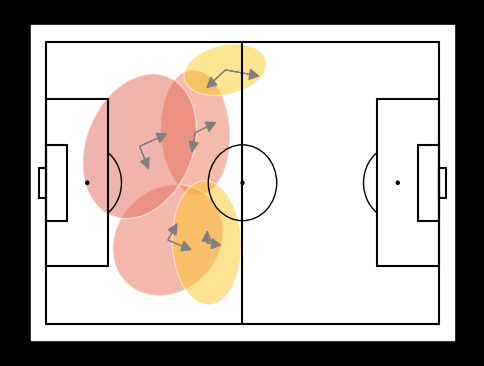

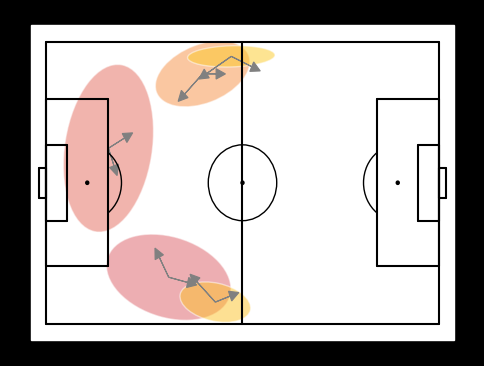

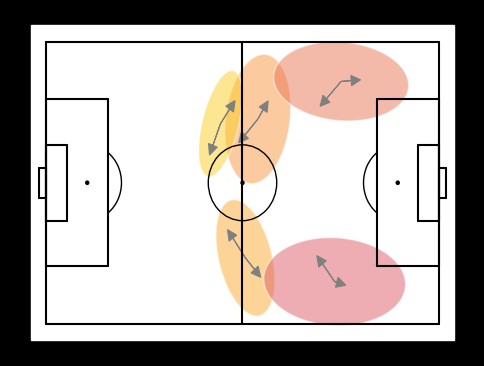

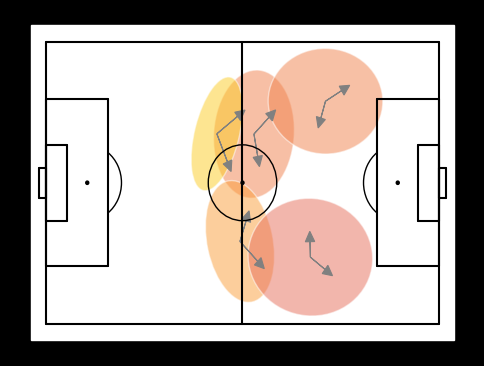

In [29]:
action_name = "pass"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Model with 2 states:


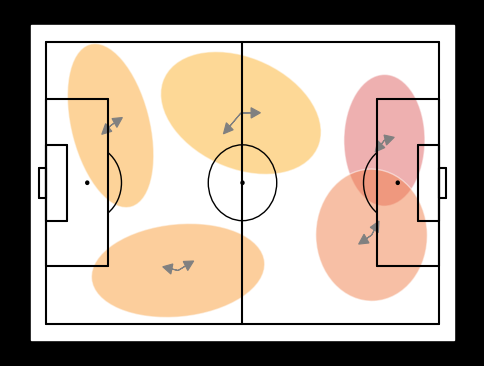

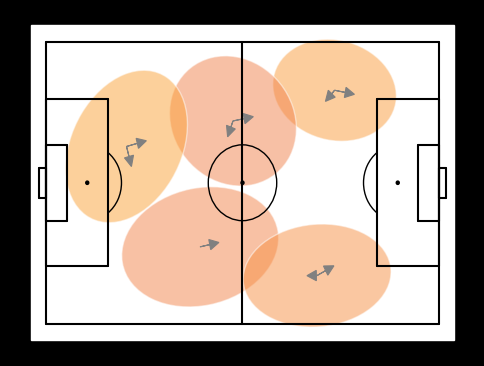

Model with 3 states:


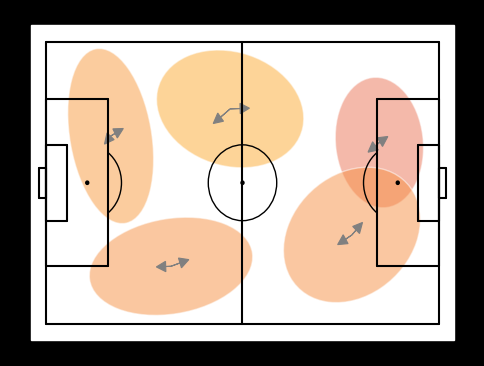

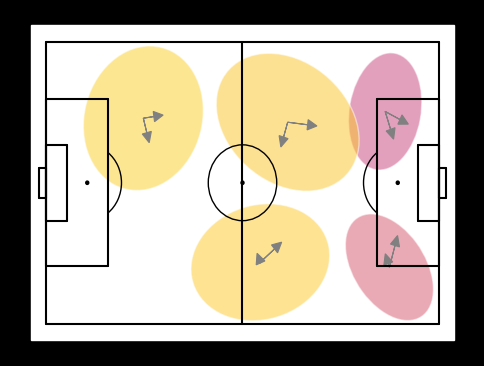

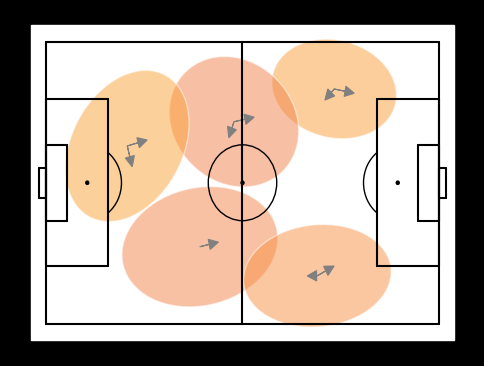

Model with 4 states:


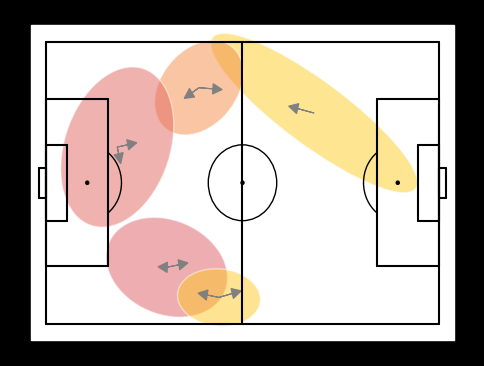

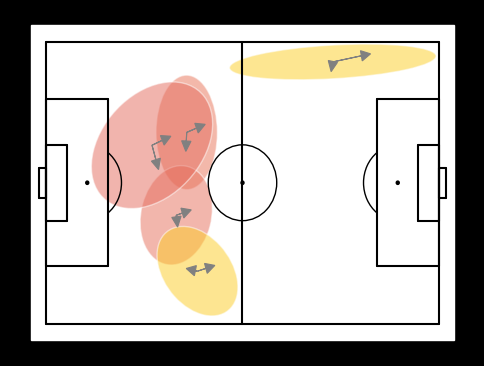

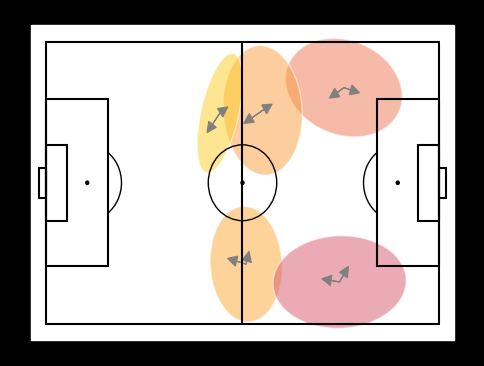

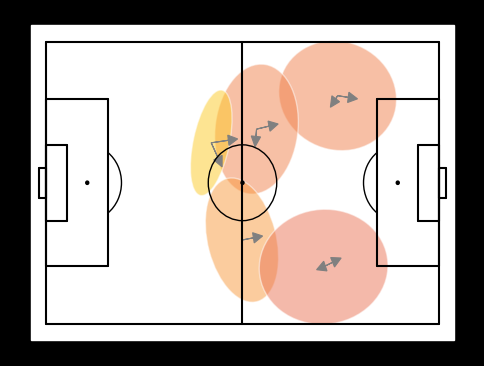

In [30]:
action_name = "dribble"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Action: clearance
Model with 2 states:


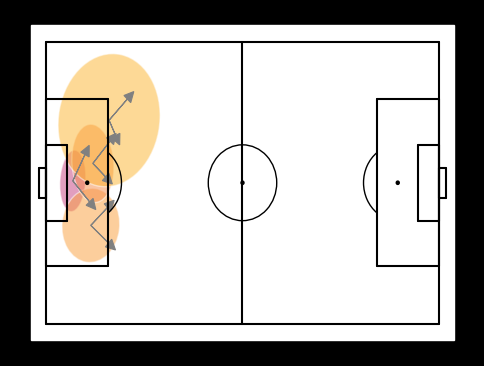

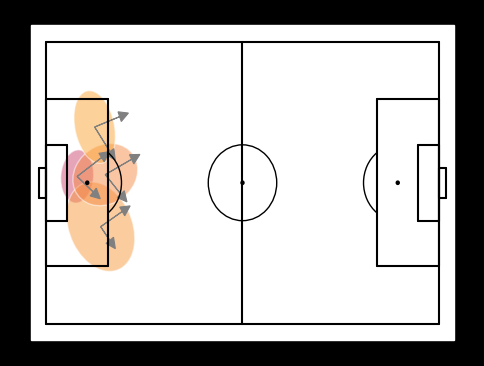

Model with 3 states:


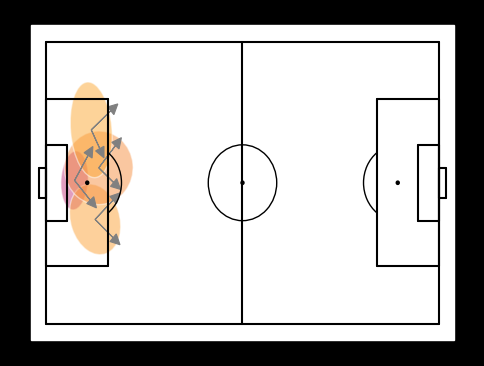

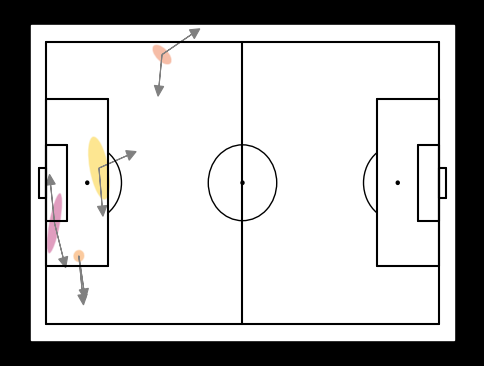

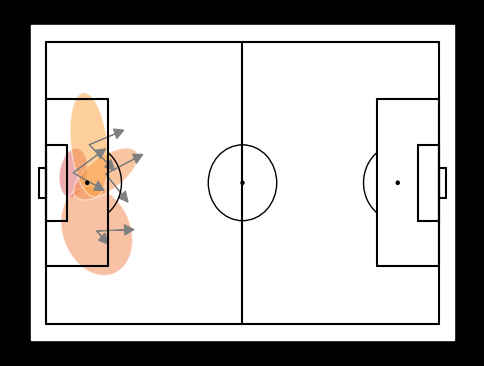

Model with 4 states:


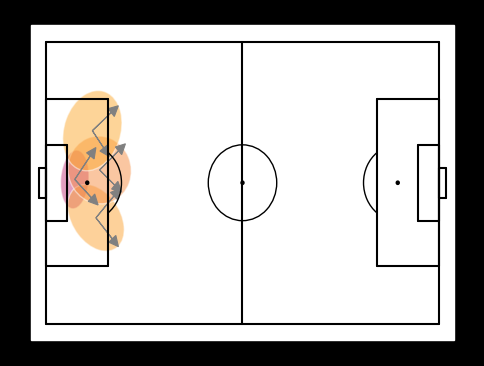

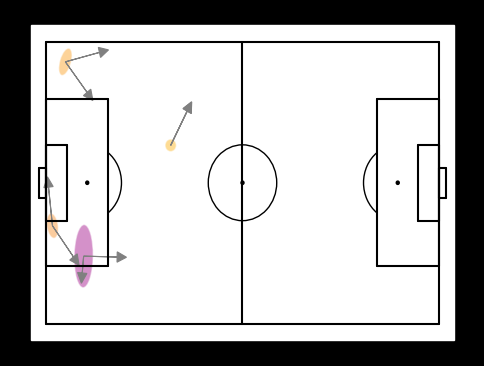

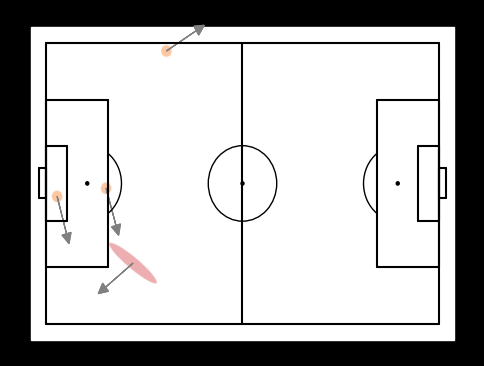

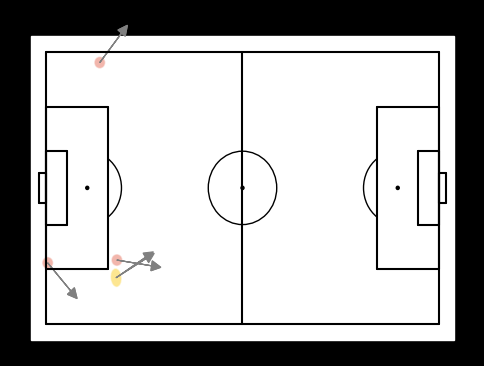

Action: corner
Model with 2 states:


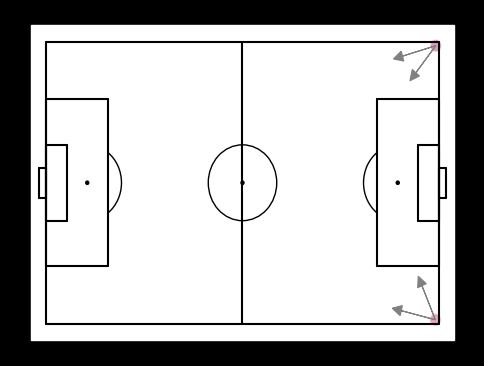

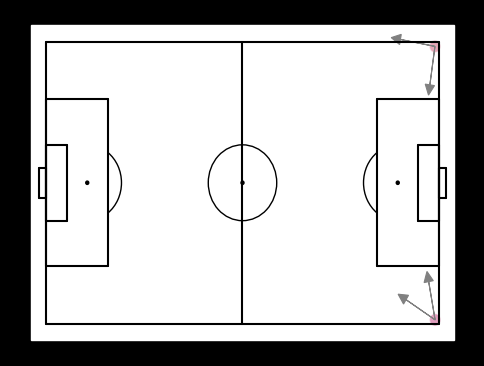

Model with 3 states:


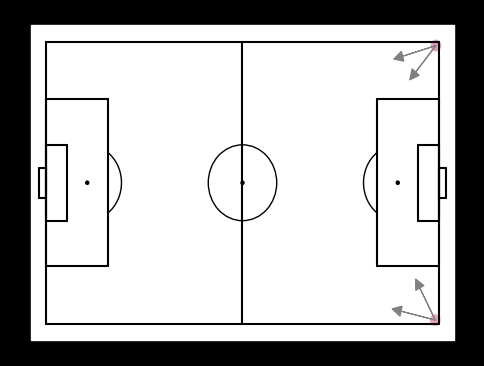

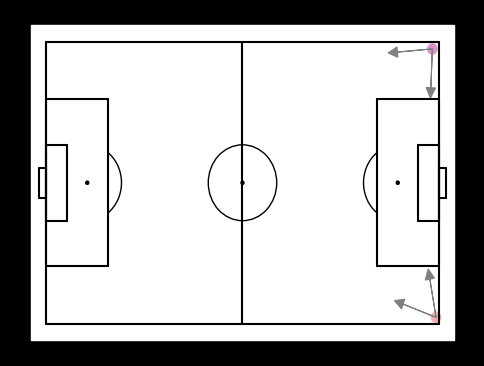

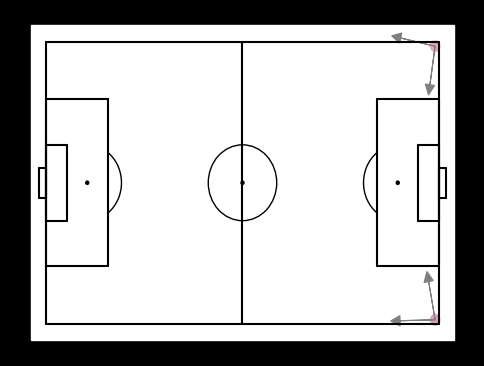

Model with 4 states:


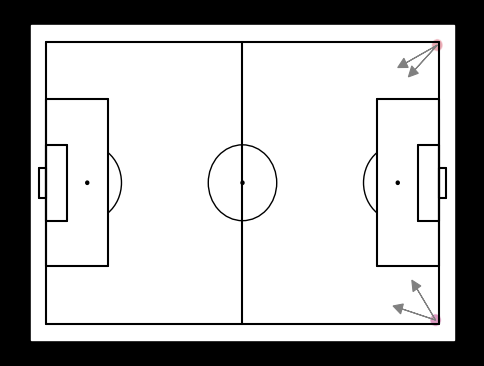

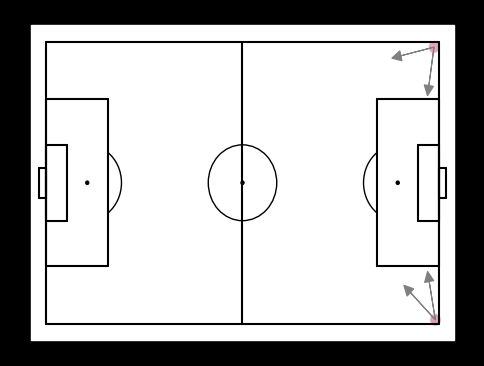

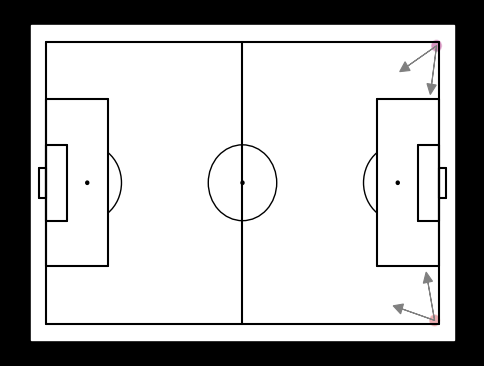

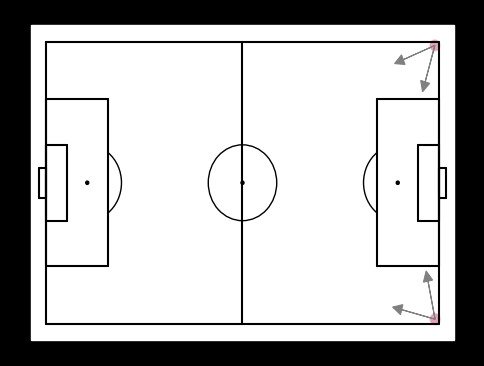

Action: cross
Model with 2 states:


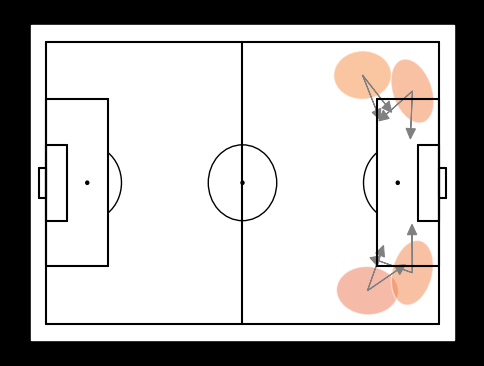

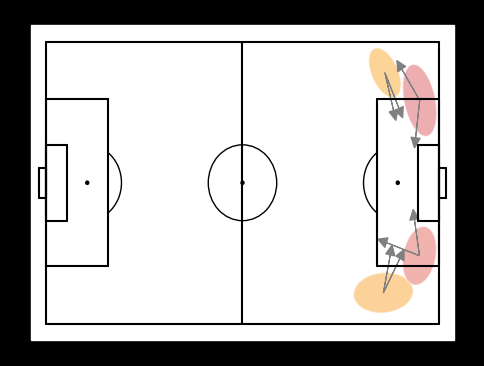

Model with 3 states:


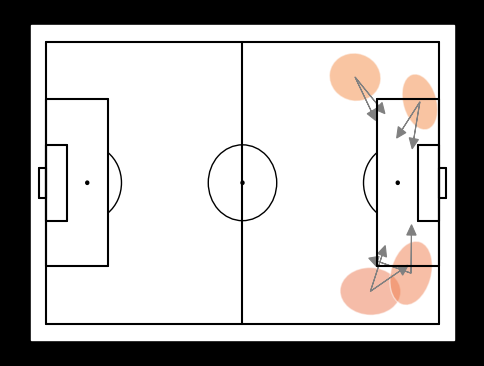

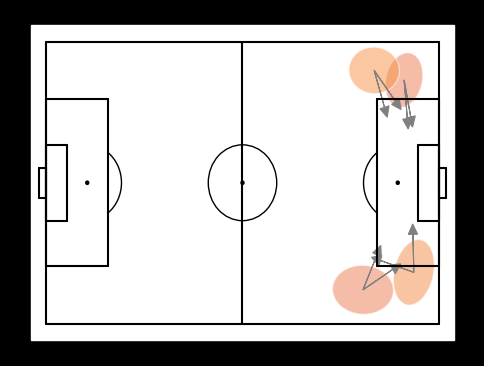

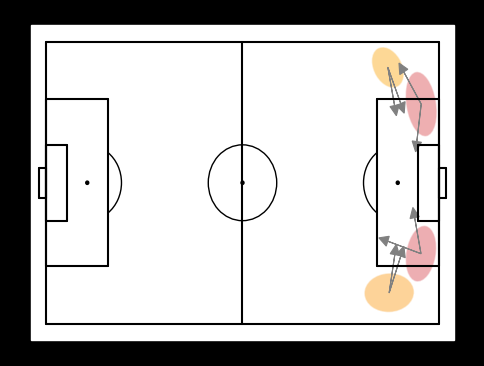

Model with 4 states:


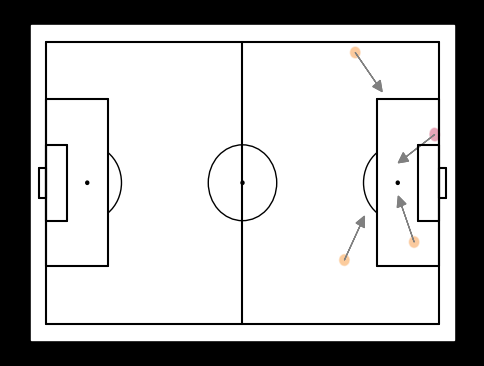

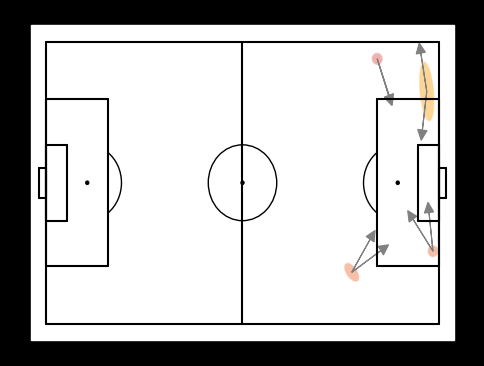

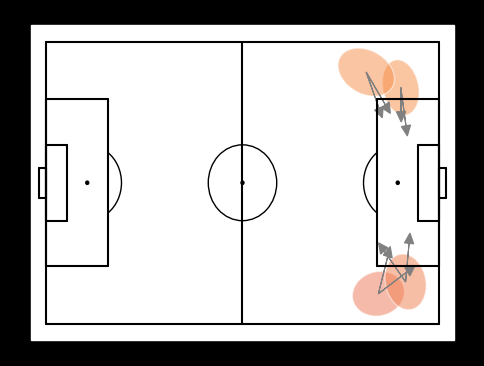

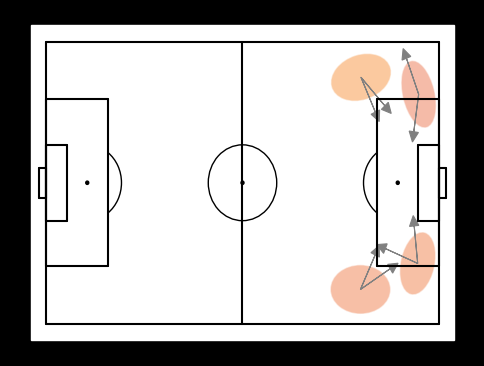

Action: dribble
Model with 2 states:


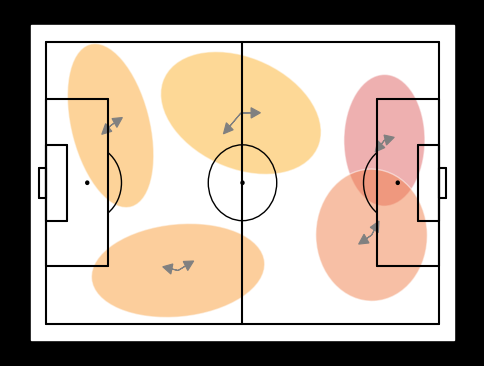

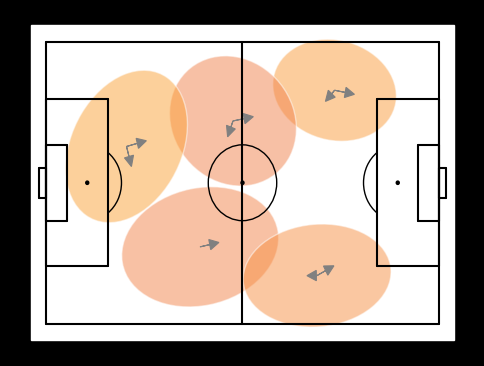

Model with 3 states:


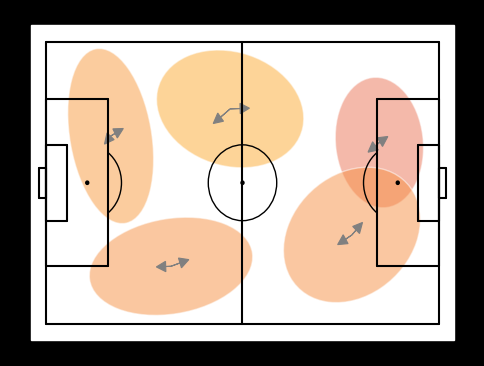

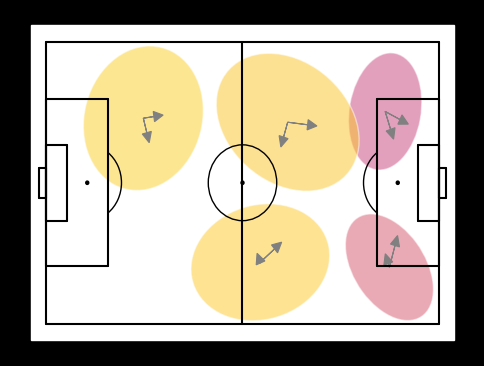

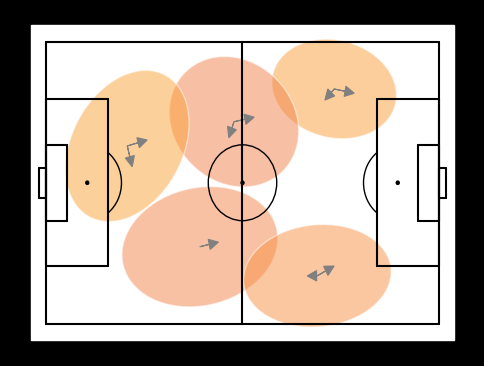

Model with 4 states:


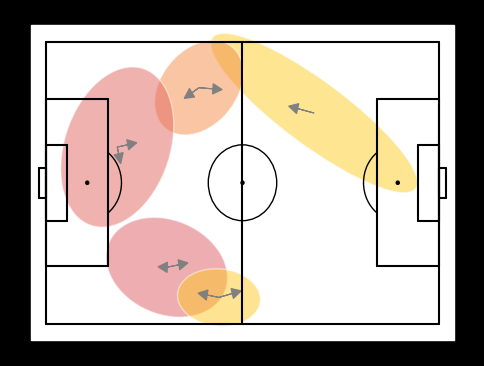

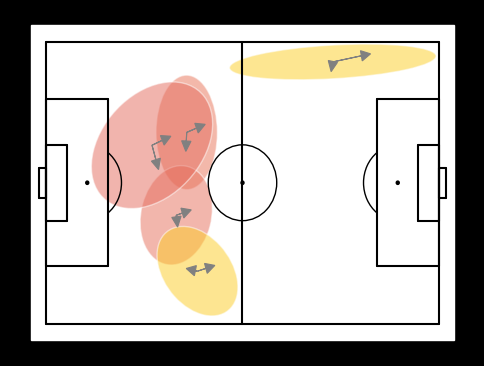

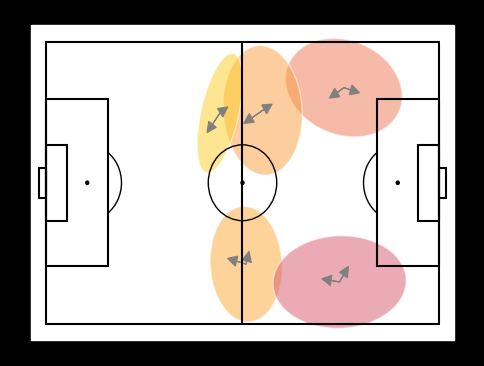

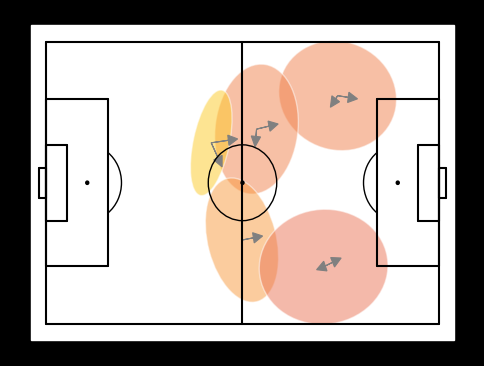

Action: freekick
Model with 2 states:


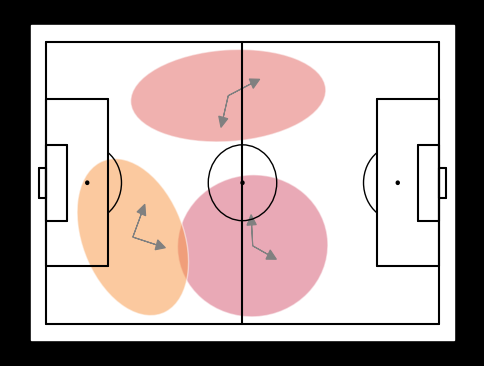

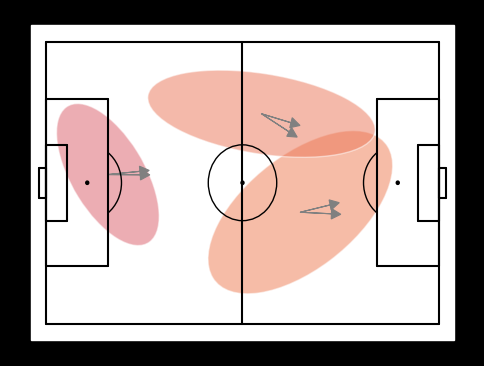

Model with 3 states:


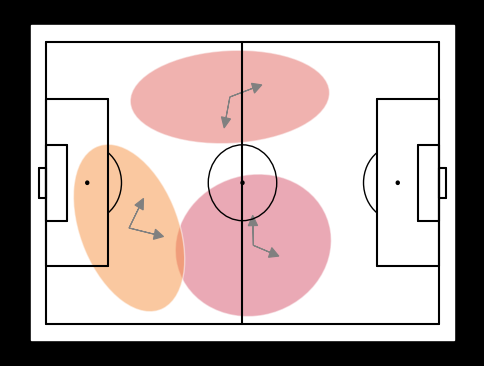

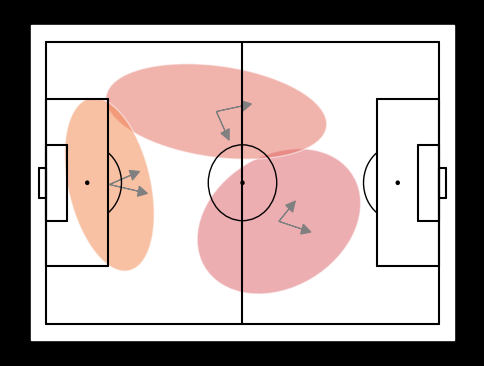

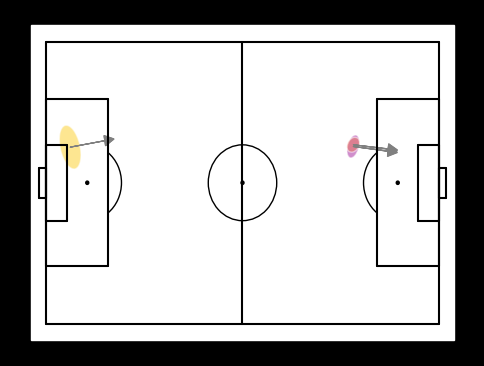

Model with 4 states:


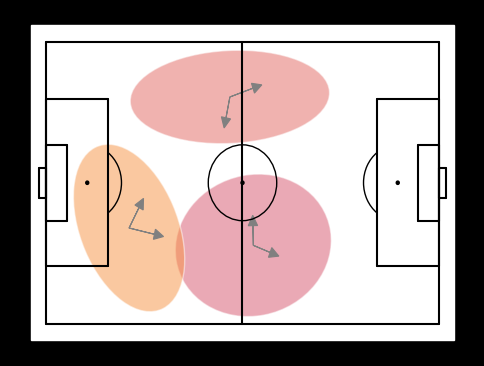

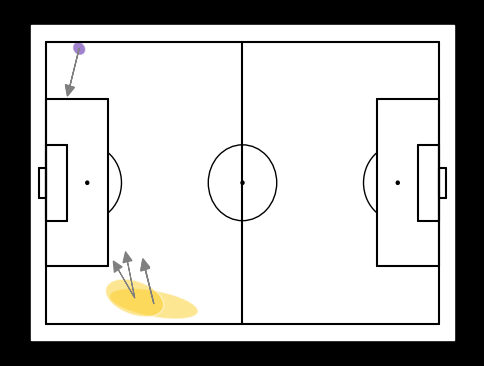

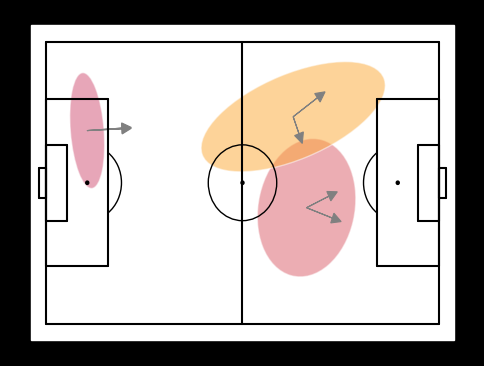

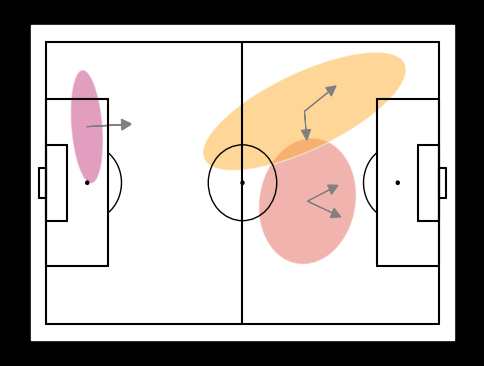

Action: goalkick
Model with 2 states:


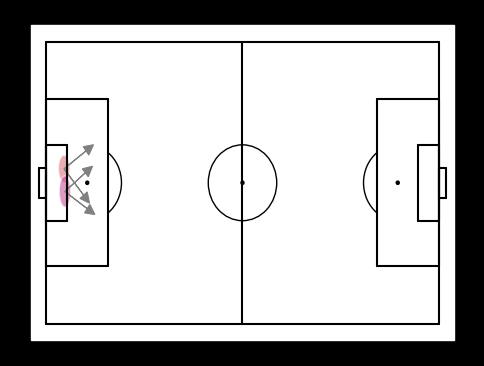

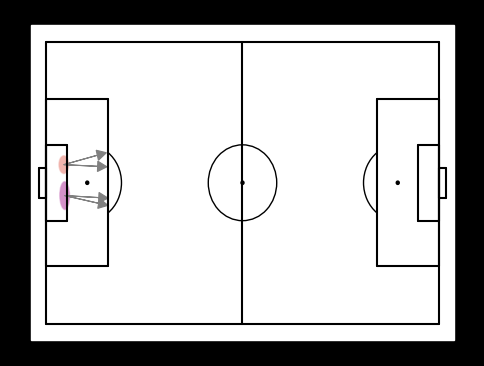

Model with 3 states:


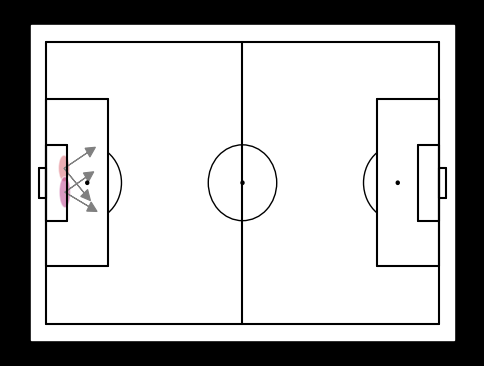

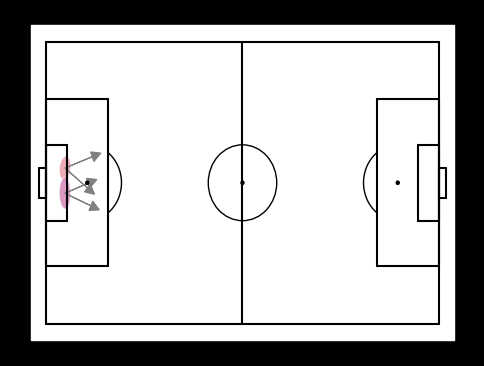

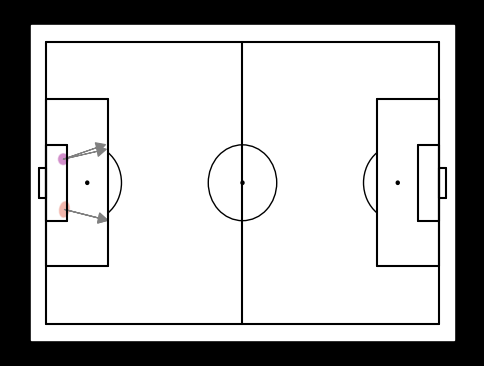

Model with 4 states:


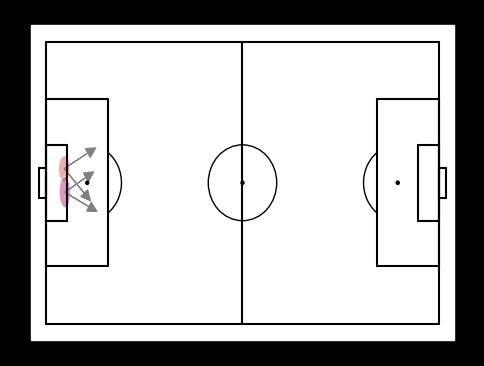

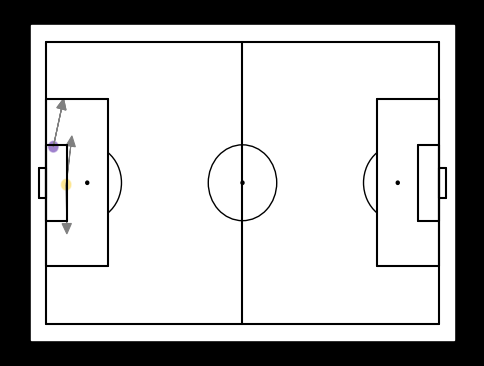

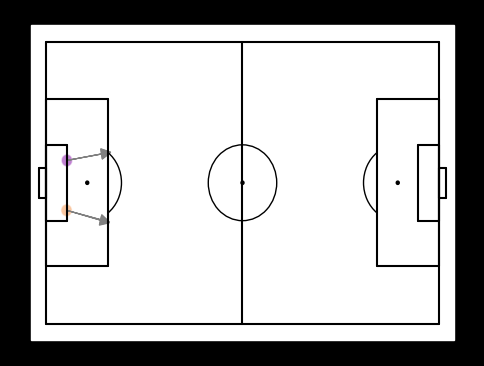

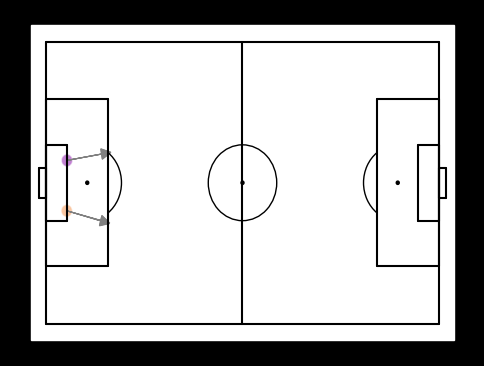

Action: keeper_action
Model with 2 states:


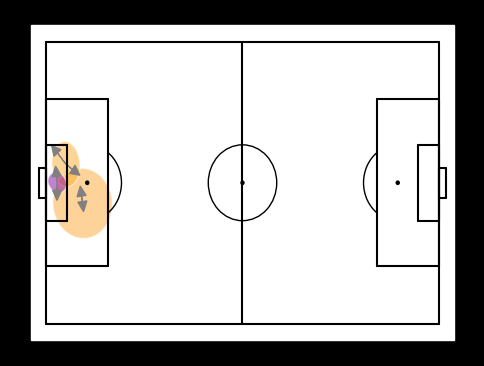

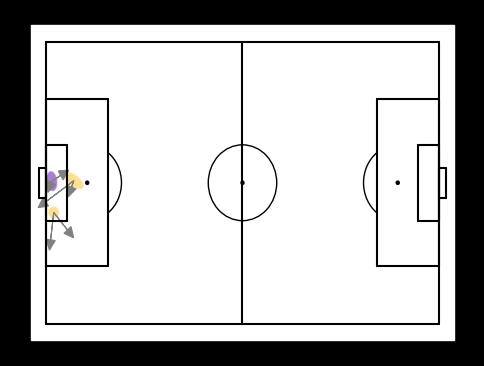

Model with 3 states:


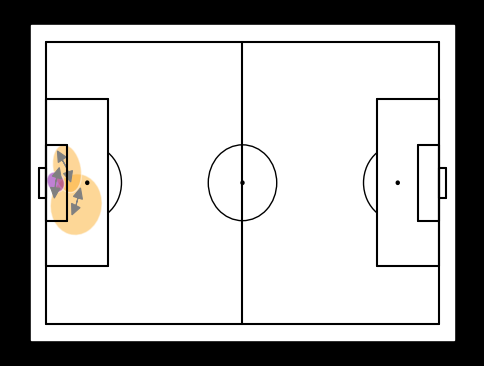

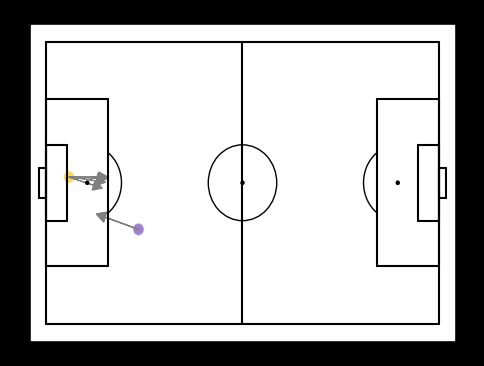

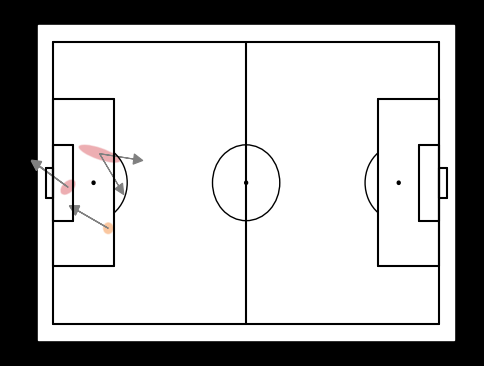

Model with 4 states:


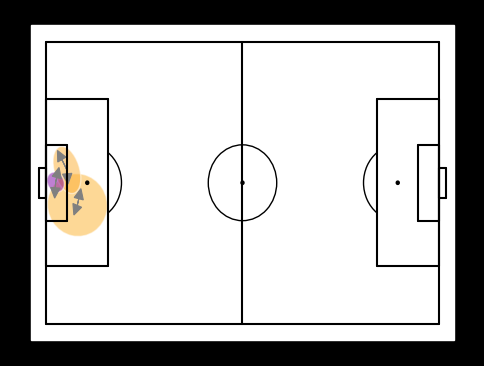

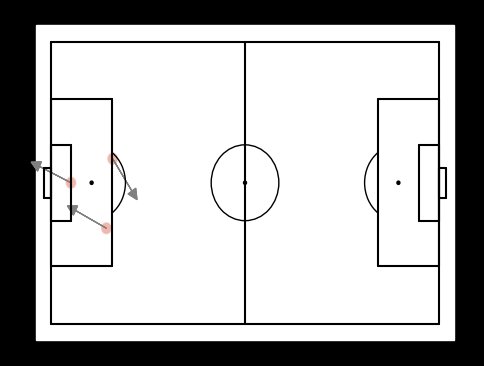

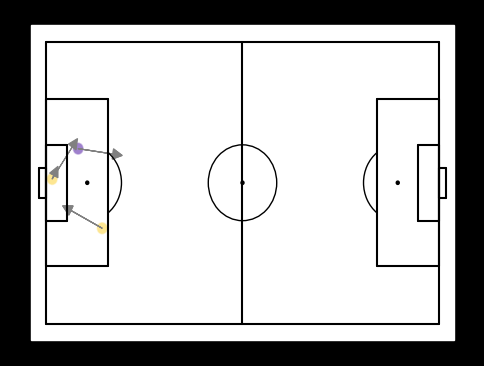

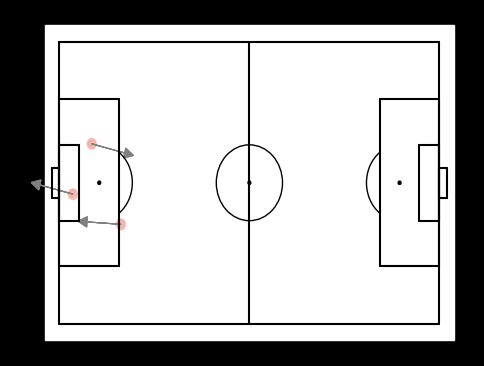

Action: pass
Model with 2 states:


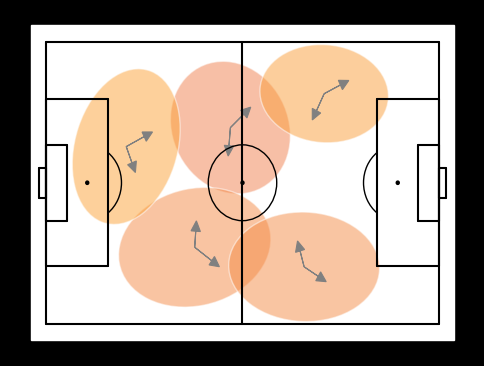

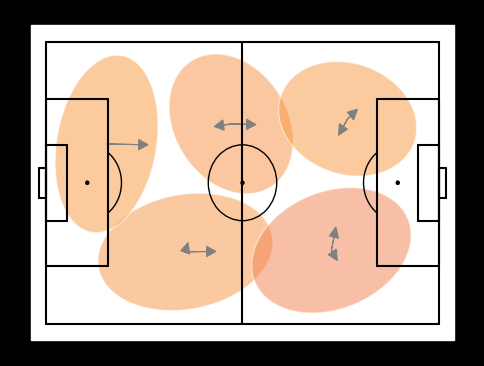

Model with 3 states:


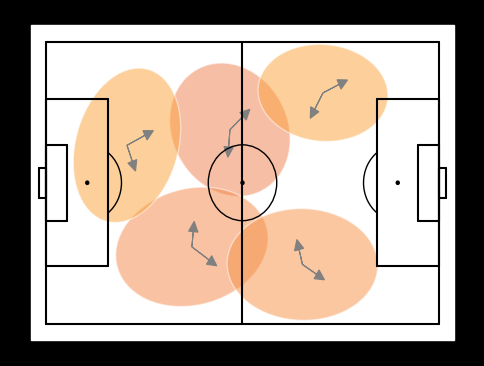

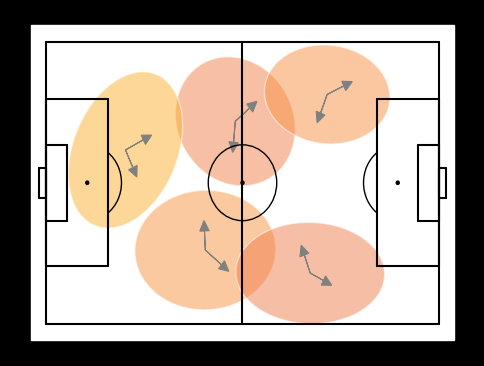

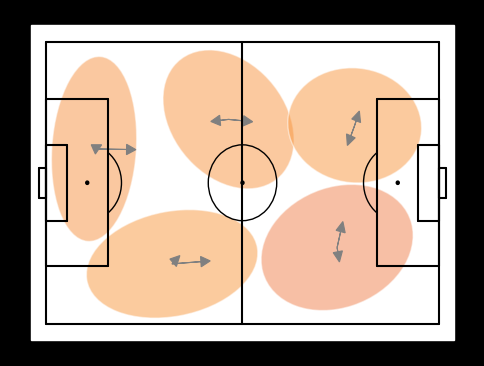

Model with 4 states:


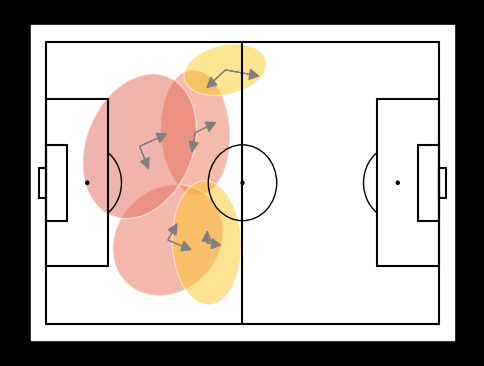

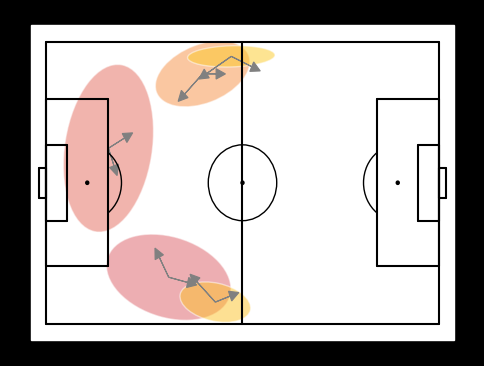

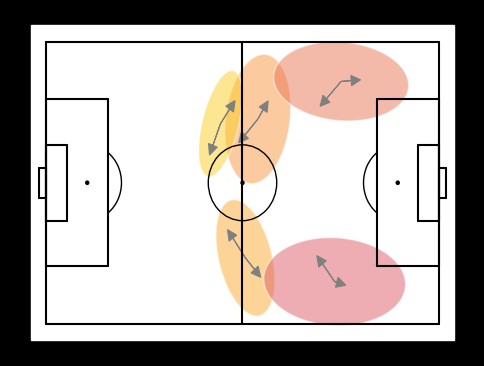

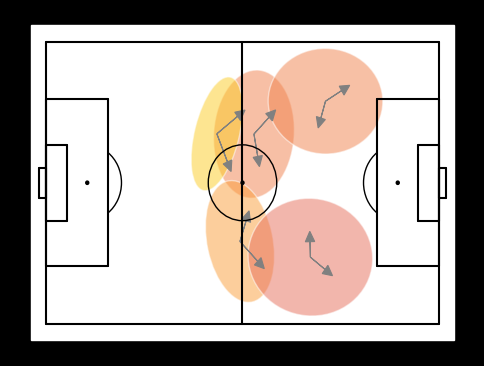

Action: shot
Model with 2 states:


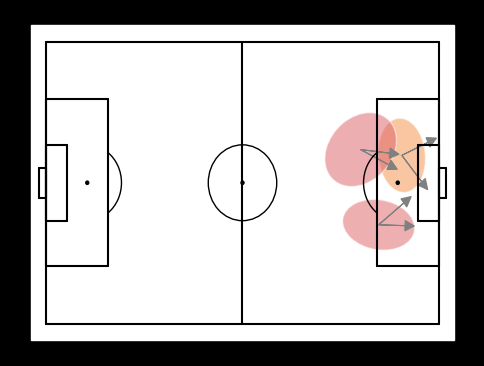

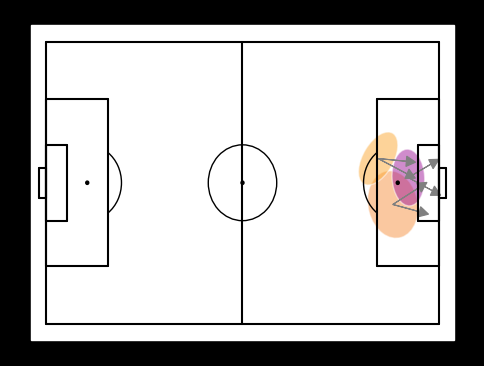

Model with 3 states:


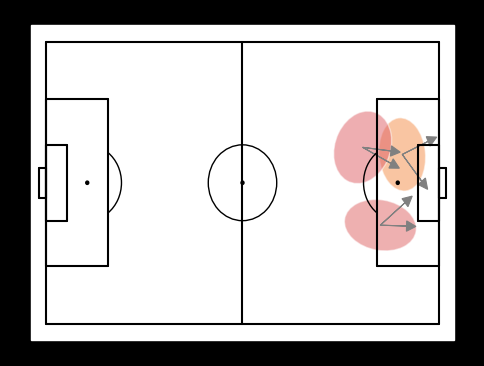

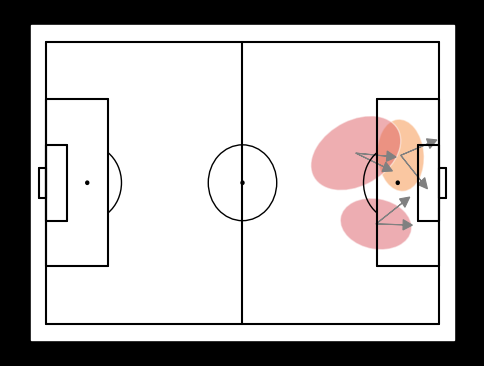

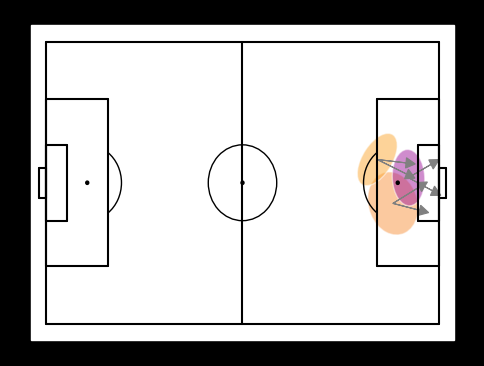

Model with 4 states:


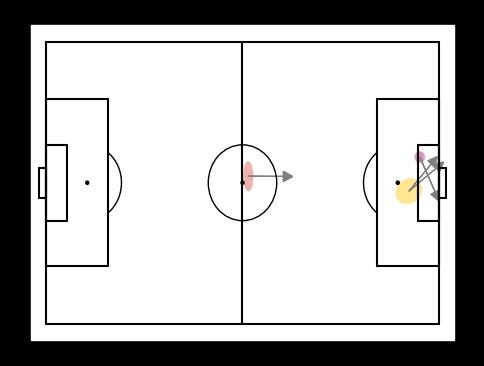

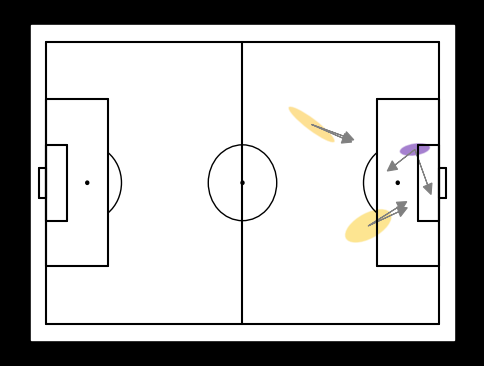

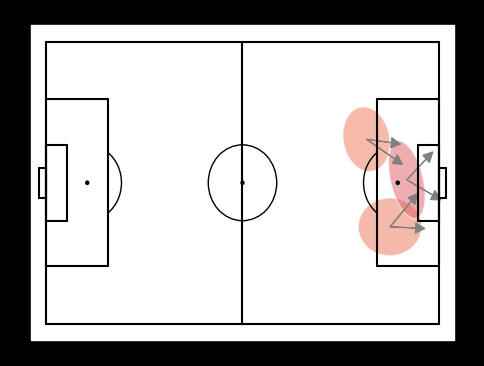

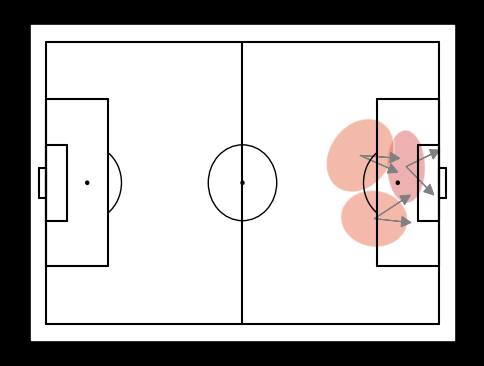

Action: throw_in
Model with 2 states:


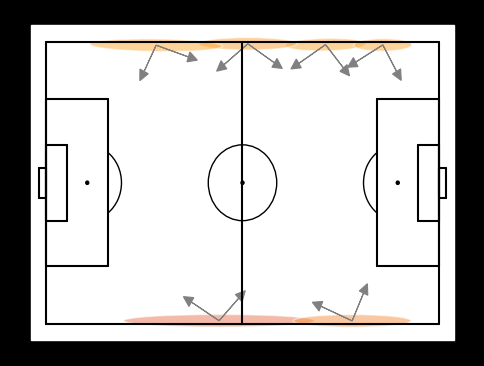

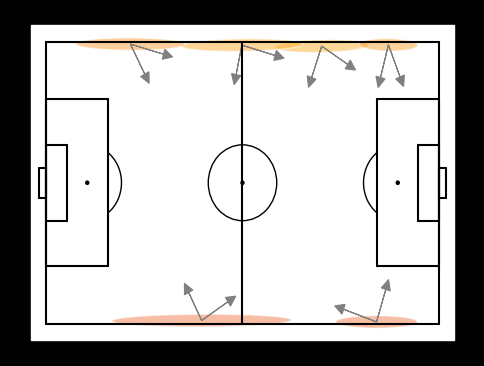

Model with 3 states:


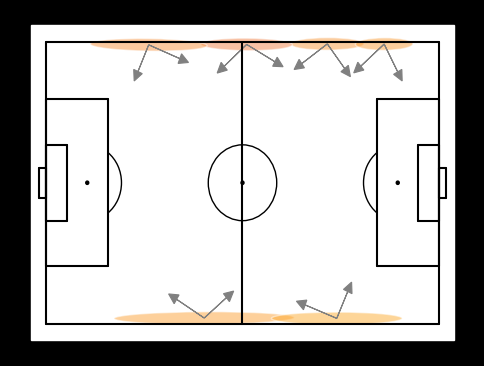

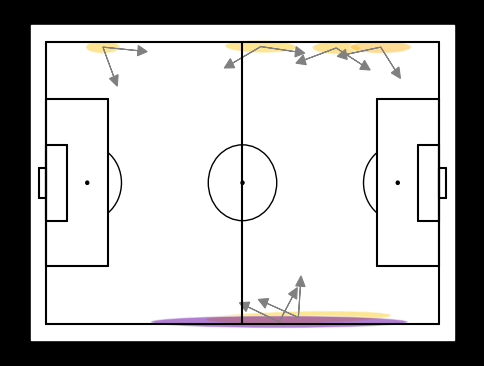

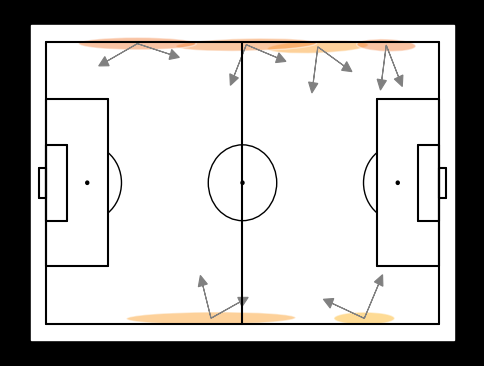

Model with 4 states:


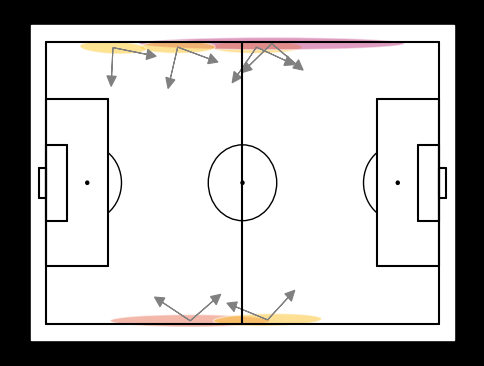

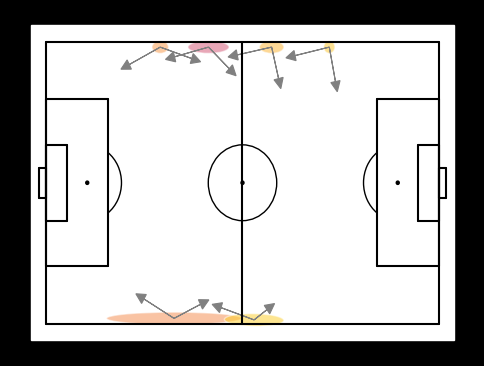

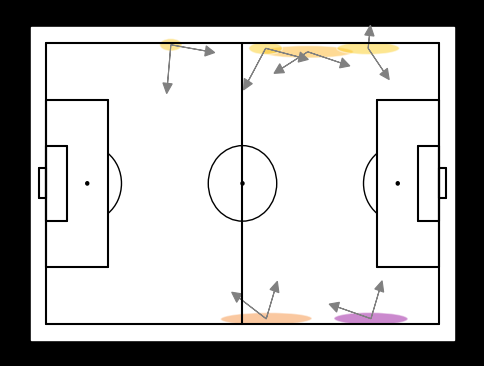

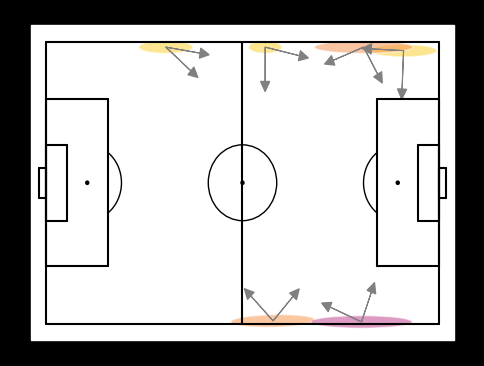

In [31]:
for action in ACTION_MAP.keys():
    print(f"Action: {action}")
    for n_state, model in models.items():
        print(f"Model with {n_state} states:")
        for state in range(n_state):
            model.emission.action_mom_[state][action].plot()